# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [ ]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA =  "VISal"       # <<<<<<<<<<  CAMBIEN ESTO

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From (original): https://drive.google.com/uc?id=1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC
From (redirected): https://drive.google.com/uc?id=1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC&confirm=t&uuid=eced08d5-ed18-4828-93eb-adbff559cded
To: /content/datos.npz
100%|██████████| 27.7M/27.7M [00:00<00:00, 83.4MB/s]


Área: VISal  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [ ]:
#Estadísticas del Paso 1

# 1. Número total de neuronas
n_neuronas = len(d["u_raton"])
print("Número total de neuronas:", n_neuronas)

# 2. Ratones distintos
ratones = np.unique(d["u_raton"])
print("\nRatones distintos:", ratones)
print("Cantidad de ratones:", len(ratones))

# 3. Ensayos por clase de estímulo
clases, conteo_clases = np.unique(d["e_clase"], return_counts=True)
print("\nEnsayos por clase de estímulo:")
for c, n in zip(clases, conteo_clases):
    print(f"  {c}: {n}")

# 4. Número total de PAs (spikes)
n_PAs = len(d["s_t"])
print("\nNúmero total de PAs (spikes):", n_PAs)

Número total de neuronas: 481

Ratones distintos: [756029989 760345702 761418226 762120172 798911424]
Cantidad de ratones: 5

Ensayos por clase de estímulo:
  drifting_gratings: 2000
  flashes: 750
  natural_movie_one: 40
  natural_scenes: 2000
  spontaneous: 750
  static_gratings: 1250

Número total de PAs (spikes): 6939713


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [ ]:
#separar ensayos por clase de estímulo

#ensayos de rejillas en movimiento
ens_rejilla = np.where(d["e_clase"] == "drifting_gratings")[0]

#ensayos espontáneos (pantalla gris)
idx_spontaneous = np.where(d["e_clase"] == "spontaneous")[0]

print("Ensayos de rejilla:", len(ens_rejilla))
print("Ensayos de espontáneo:", len(idx_spontaneous))

Ensayos de rejilla: 2000
Ensayos de espontáneo: 750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [ ]:
import pandas as pd

# ---- Tabla de neuronas (una fila por neurona) ----
tabla_neuronas = pd.DataFrame({
    "u_id": d["u_id"],
    "u_raton": d["u_raton"],
    "u_canal": d["u_canal"],
    "u_profundidad": d["u_profundidad"],
    "u_snr": d["u_snr"],
    "u_firing_rate": d["u_firing_rate"],
})

# ---- Tabla de ensayos (una fila por ensayo) ----
tabla_ensayos = pd.DataFrame({
    "e_clase": d["e_clase"],
    "e_raton": d["e_raton"],
    "e_orientacion": d["e_orientacion"],
    "e_frec_temporal": d["e_frec_temporal"],
    "e_frec_espacial": d["e_frec_espacial"],
    "e_contraste": d["e_contraste"],
})

# ---- Tabla de spikes / PAs (una fila por spike) ----
tabla_espigas = pd.DataFrame({
    "s_unidad": d["s_unidad"],
    "s_ensayo": d["s_ensayo"],
    "s_t": d["s_t"],
})

print("Tabla de neuronas:")
display(tabla_neuronas.head())

print("\nTabla de ensayos:")
display(tabla_ensayos.head())

print("\nTabla de spikes:")
display(tabla_espigas.head())


# Cálculo de tasa evocada (rejillas) y tasa basal (espontáneo)

n_neuronas = len(d["u_id"])
n_ensayos  = len(d["e_clase"])

s_unidad = d["s_unidad"]   # índice de neurona por spike
s_ensayo = d["s_ensayo"]   # índice de ensayo por spike
s_t      = d["s_t"]        # tiempo del spike relativo al inicio del ensayo

# ventana de interés: 0 a 2 segundos
mask_ventana = (s_t >= 0) & (s_t <= 2)

# mapeo de cada ensayo global a su posición dentro de idx_gratings / idx_spontaneous
pos_en_gratings = -np.ones(n_ensayos, dtype=int)
pos_en_gratings[ens_rejilla] = np.arange(len(ens_rejilla))

pos_en_espontaneo = -np.ones(n_ensayos, dtype=int)
pos_en_espontaneo[idx_spontaneous] = np.arange(len(idx_spontaneous))

# matrices de conteo: una fila por neurona, una columna por ensayo
conteo_evocada = np.zeros((n_neuronas, len(ens_rejilla)))
conteo_basal   = np.zeros((n_neuronas, len(idx_spontaneous)))

# spikes dentro de la ventana que caen en un ensayo de rejilla
es_spike_rejilla = mask_ventana & (pos_en_gratings[s_ensayo] >= 0)
np.add.at(
    conteo_evocada,
    (s_unidad[es_spike_rejilla], pos_en_gratings[s_ensayo[es_spike_rejilla]]),
    1
)

# spikes dentro de la ventana que caen en un ensayo espontáneo
es_spike_espontaneo = mask_ventana & (pos_en_espontaneo[s_ensayo] >= 0)
np.add.at(
    conteo_basal,
    (s_unidad[es_spike_espontaneo], pos_en_espontaneo[s_ensayo[es_spike_espontaneo]]),
    1
)

# tasa en Hz = conteo / duración de la ventana (2 s)
tasa_evocada = conteo_evocada / 2.0
tasa_basal   = conteo_basal / 2.0

print("\nForma de tasa_evocada:", tasa_evocada.shape)
print("Forma de tasa_basal:", tasa_basal.shape)


# Verificación: mediana emparejando cada neurona con su ratón

medianas_por_neurona = []

for raton in np.unique(d["u_raton"]):
    neuronas_raton = np.where(d["u_raton"] == raton)[0]
    grat_raton = np.where(d["e_raton"][ens_rejilla] == raton)[0]  # posiciones dentro de idx_gratings

    for n in neuronas_raton:
        medianas_por_neurona.append(np.median(tasa_evocada[n, grat_raton]))

print("Mediana tasa evocada (bien emparejada):", np.median(medianas_por_neurona))

Tabla de neuronas:


,u_id,u_raton,u_canal,u_profundidad,u_snr,u_firing_rate
0,951893103,761418226,850083290,2360.0,2.242198,22.665325
1,951893165,761418226,850083302,2420.0,3.272630,7.914339
2,951893203,761418226,850083314,2480.0,1.835917,18.113108
3,951893228,761418226,850083318,2500.0,1.619858,16.340958
4,951893210,761418226,850083318,2500.0,2.648995,13.955221



Tabla de ensayos:


,e_clase,e_raton,e_orientacion,e_frec_temporal,e_frec_espacial,e_contraste
0,drifting_gratings,761418226,0.0,8.0,0.04,0.8
1,drifting_gratings,761418226,270.0,1.0,0.04,0.8
2,drifting_gratings,761418226,45.0,1.0,0.04,0.8
3,drifting_gratings,761418226,225.0,8.0,0.04,0.8
4,drifting_gratings,761418226,90.0,15.0,0.04,0.8



Tabla de spikes:


,s_unidad,s_ensayo,s_t
0,0,958,0.071586
1,0,958,0.083153
2,0,958,0.087586
3,0,958,0.092986
4,0,958,0.098353



Forma de tasa_evocada: (481, 2000)
Forma de tasa_basal: (481, 750)
Mediana tasa evocada (bien emparejada): 2.0



--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [ ]:
# Paso 4: Z-score por condición, tomando el máximo por neurona

ratones = np.unique(d["u_raton"])
e_orientacion = d["e_orientacion"]
e_frec_temporal = d["e_frec_temporal"]
e_frec_espacial = d["e_frec_espacial"]

z_scores = np.full(n_neuronas, np.nan)

for raton in ratones:
    neuronas_raton = np.where(d["u_raton"] == raton)[0]

    grat_raton  = np.where(d["e_raton"][ens_rejilla] == raton)[0]
    basal_raton = np.where(d["e_raton"][idx_spontaneous] == raton)[0]

    orient = e_orientacion[ens_rejilla][grat_raton]
    tf     = e_frec_temporal[ens_rejilla][grat_raton]
    sf     = e_frec_espacial[ens_rejilla][grat_raton]

    # excluir los que no son una combinación real de estímulo
    mask_valido = ~np.isnan(orient) & ~np.isnan(tf) & ~np.isnan(sf)
    grat_raton = grat_raton[mask_valido]
    orient = orient[mask_valido]
    tf = tf[mask_valido]
    sf = sf[mask_valido]

    combos = np.stack([orient, tf, sf], axis=1)
    combos_unicas, combo_id = np.unique(combos, axis=0, return_inverse=True)

    for n in neuronas_raton:
        tasas_neurona = tasa_evocada[n, grat_raton]
        basal_media   = tasa_basal[n, basal_raton].mean()
        basal_std     = tasa_basal[n, basal_raton].std()

        if basal_std == 0:
            continue

        z_por_condicion = np.array([
            (tasas_neurona[combo_id == c].mean() - basal_media) / basal_std
            for c in range(len(combos_unicas))
        ])

        z_scores[n] = z_por_condicion.max()

UMBRAL = 2.5
responde = z_scores >= UMBRAL
fraccion = np.nanmean(responde)

print(f"Responden {responde.sum()} de {n_neuronas} neuronas")
print(f"Fracción respondedora = {fraccion*100:.1f}%")

Responden 188 de 481 neuronas
Fracción respondedora = 39.1%


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [ ]:
resultados_por_raton = {}

for raton in ratones:
    neuronas_raton = np.where(d["u_raton"] == raton)[0]
    z_scores_raton = z_scores[neuronas_raton]  # ya calculados en el Paso 4

    responde_raton = z_scores_raton >= UMBRAL
    fraccion_raton = np.nanmean(responde_raton)

    resultados_por_raton[raton] = {
        "n_neuronas": len(neuronas_raton),
        "n_responden": int(np.nansum(responde_raton)),
        "fraccion": fraccion_raton
    }

print("Fracción respondedora por ratón:\n")
for raton, res in resultados_por_raton.items():
    print(f"Ratón {raton}: {res['n_responden']} de {res['n_neuronas']} neuronas "
          f"→ {res['fraccion']*100:.1f}%")

Fracción respondedora por ratón:

Ratón 756029989: 27 de 52 neuronas → 51.9%
Ratón 760345702: 24 de 57 neuronas → 42.1%
Ratón 761418226: 66 de 188 neuronas → 35.1%
Ratón 762120172: 35 de 92 neuronas → 38.0%
Ratón 798911424: 36 de 92 neuronas → 39.1%


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

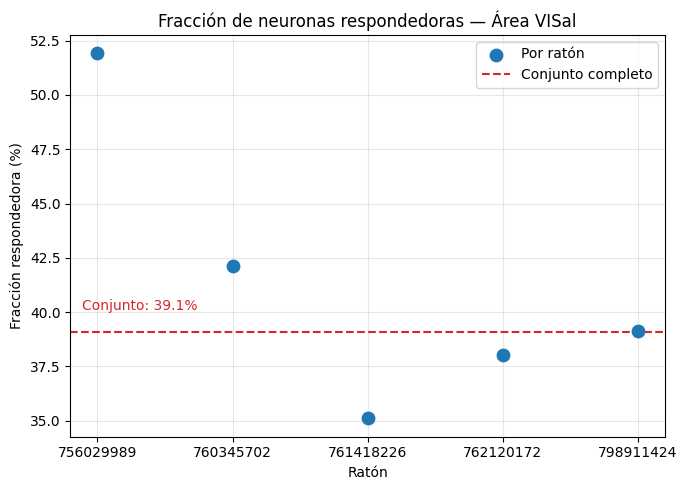

In [ ]:
import matplotlib.pyplot as plt

claves_raton = list(resultados_por_raton.keys())          # claves originales (numéricas) para indexar
nombres_raton = [str(r) for r in claves_raton]              # versión texto solo para las etiquetas del eje

fracciones_raton = [resultados_por_raton[r]["fraccion"] * 100 for r in claves_raton]

fraccion_global = fraccion * 100

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(nombres_raton, fracciones_raton, s=80, color="tab:blue", zorder=3, label="Por ratón")

ax.axhline(fraccion_global, color="tab:red", linestyle="--", linewidth=1.5, label="Conjunto completo")

ax.text(0.02, fraccion_global + 1, f"Conjunto: {fraccion_global:.1f}%",
        color="tab:red", transform=ax.get_yaxis_transform())

ax.set_xlabel("Ratón")
ax.set_ylabel("Fracción respondedora (%)")
ax.set_title(f"Fracción de neuronas respondedoras — Área {MI_AREA}")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.

**GRAFICAS**

**FIGURA 1** *FORMA DE ONDA DE LA NEURONA*

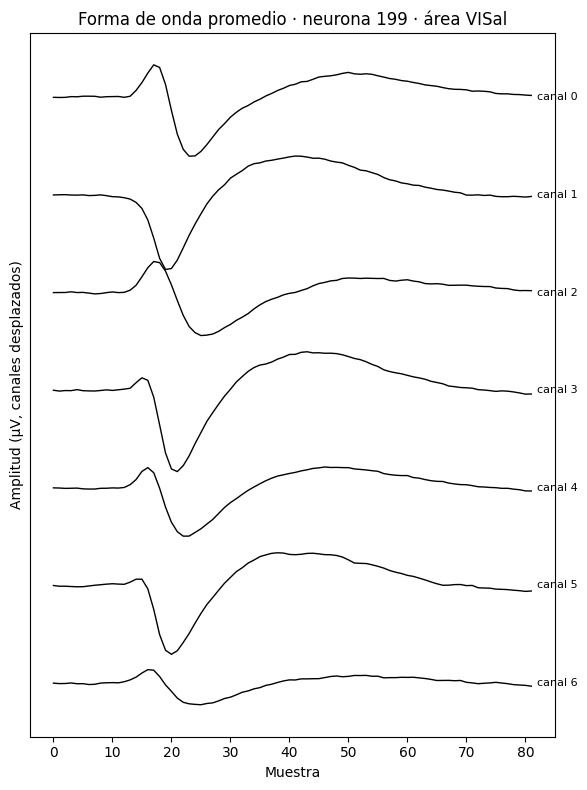

In [ ]:
# Figura 1, Panel C: forma de onda de la neurona ejemplo (7 canales)

n_ejemplo = np.nanargmax(z_scores)
onda_ejemplo = d["u_onda"][n_ejemplo]  # canales, muestras

n_canales, n_muestras = onda_ejemplo.shape
x = np.arange(n_muestras)

separacion = 1.2 * np.max(np.abs(onda_ejemplo))

plt.figure(figsize=(6, 8))
for canal in range(n_canales):
    offset = -canal * separacion
    plt.plot(x, onda_ejemplo[canal] + offset, color="black", linewidth=1)
    plt.text(x[-1] + 1, offset, f"canal {canal}", va="center", fontsize=8)

plt.xlabel("Muestra")
plt.ylabel("Amplitud (µV, canales desplazados)")
plt.yticks([])
plt.title(f"Forma de onda promedio · neurona {n_ejemplo} · área {MI_AREA}")
plt.tight_layout()
plt.show()

Esta imagen nos muestra cómo la neurona ejemplo se activo y se registró en varios canales al mismo tiempo. Cada línea es un canal distinto. El canal que está más cerca de la neurona (el 5) lo captó más fuerte, y los que están más lejos (como el 0 o el 6) lo captaron más débil.

---



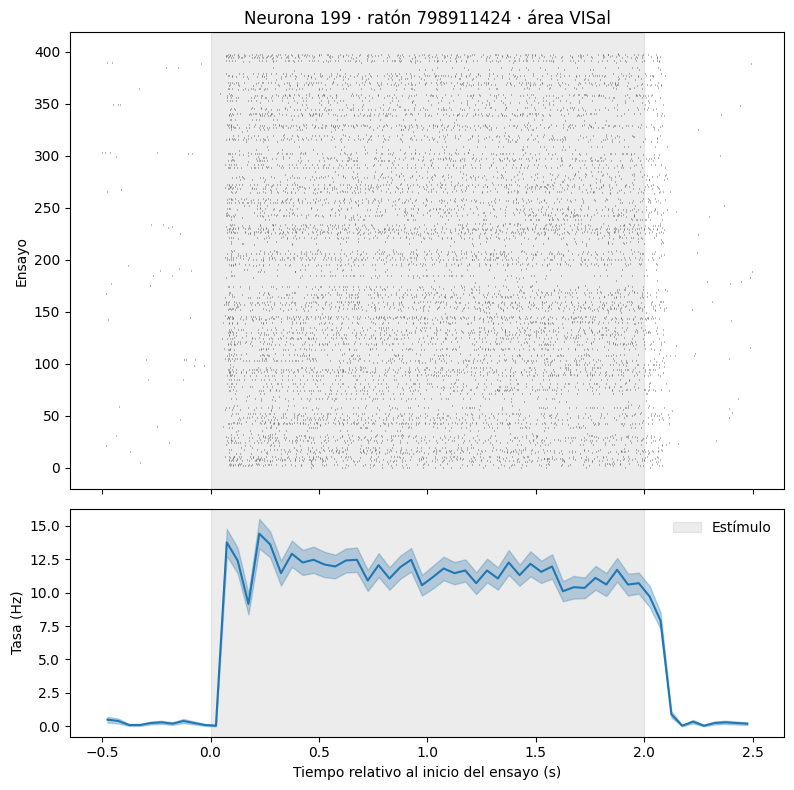

In [ ]:
#Panel D: raster + PSTH con sombreado de SEM, de la misma neurona ejemplo

s_unidad = d["s_unidad"]   # índice de neurona por spike
s_ensayo = d["s_ensayo"]   # índice de ensayo por spike
s_t      = d["s_t"]        # tiempo del spike relativo al inicio del ensayo

def alinear_neurona(n, indices_ensayo, ventana=(-0.5, 2.5)):

    spikes_de_n = s_t[s_unidad == n]
    ensayo_de_esos_spikes = s_ensayo[s_unidad == n]

    alineados = []
    for e in indices_ensayo:
        en_este_ensayo = spikes_de_n[ensayo_de_esos_spikes == e]
        en_ventana = en_este_ensayo[(en_este_ensayo >= ventana[0]) & (en_este_ensayo <= ventana[1])]
        alineados.append(en_ventana)
    return alineados
raton_ejemplo = d["u_raton"][n_ejemplo]
ensayos_ejemplo = ens_rejilla[d["e_raton"][ens_rejilla] == raton_ejemplo]

raster_ejemplo = alinear_neurona(n_ejemplo, ensayos_ejemplo, ventana=(-0.5, 2.5))

# PSTH: histograma de tasa por bin, promediado sobre ensayo
bin_size = 0.05  # 50 ms
bordes = np.arange(-0.5, 2.5 + bin_size, bin_size)
centros = bordes[:-1] + bin_size / 2

conteos_por_ensayo = np.array([
    np.histogram(spikes, bins=bordes)[0] / bin_size   # tasa en Hz por bin
    for spikes in raster_ejemplo
])

psth_media = conteos_por_ensayo.mean(axis=0)
psth_sem   = conteos_por_ensayo.std(axis=0) / np.sqrt(len(raster_ejemplo))

fig, (ax_raster, ax_psth) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                          gridspec_kw={"height_ratios": [2, 1]})

# raster
for fila, spikes in enumerate(raster_ejemplo):
    ax_raster.vlines(spikes, fila, fila + 0.9, color="black", linewidth=0.4)
ax_raster.axvspan(0, 2, color="gray", alpha=0.15)
ax_raster.set_ylabel("Ensayo")
ax_raster.set_title(f"Neurona {n_ejemplo} · ratón {raton_ejemplo} · área {MI_AREA}")

# PSTH
ax_psth.plot(centros, psth_media, color="tab:blue")
ax_psth.fill_between(centros, psth_media - psth_sem, psth_media + psth_sem,
                      color="tab:blue", alpha=0.3)
ax_psth.axvspan(0, 2, color="gray", alpha=0.15, label="Estímulo")
ax_psth.set_xlabel("Tiempo relativo al inicio del ensayo (s)")
ax_psth.set_ylabel("Tasa (Hz)")
ax_psth.legend(frameon=False)

plt.tight_layout()
plt.show()

**FIGURA 2**

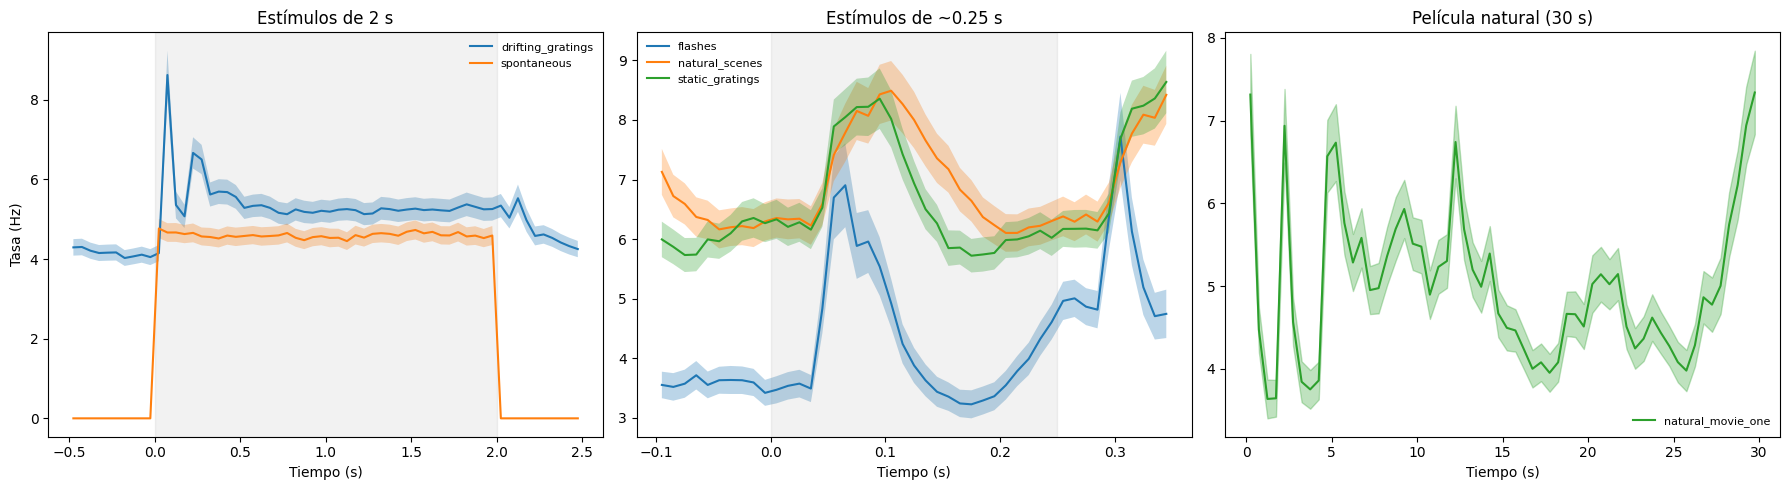

In [ ]:
# Figura 2, Panel B: PSTH poblacional por clase de estímulo, agrupado por ventana de duración

n_neuronas = len(d["u_id"])
ratones = np.unique(d["u_raton"])
n_ratones = len(ratones)

s_unidad = d["s_unidad"]
s_ensayo = d["s_ensayo"]
s_t      = d["s_t"]

e_clase_spike  = d["e_clase"][s_ensayo]   # clase del ensayo de cada spike
raton_ensayo   = d["e_raton"][s_ensayo]   # ratón del ensayo de cada spike
raton_neurona  = d["u_raton"][s_unidad]   # ratón de la neurona de cada spike
mismo_raton    = raton_ensayo == raton_neurona   # el emparejamiento crítico

def psth_poblacional(clase, bin_size, ventana):
    idx_clase = np.where(d["e_clase"] == clase)[0]
    n_trials_por_raton = len(idx_clase) / n_ratones

    bordes = np.arange(ventana[0], ventana[1] + bin_size, bin_size)
    centros = bordes[:-1] + bin_size / 2
    n_bins = len(centros)

    en_ventana = (s_t >= ventana[0]) & (s_t < ventana[1])
    mask = (e_clase_spike == clase) & mismo_raton & en_ventana

    bin_idx = np.clip(np.digitize(s_t[mask], bordes) - 1, 0, n_bins - 1)

    conteo = np.zeros((n_neuronas, n_bins))
    np.add.at(conteo, (s_unidad[mask], bin_idx), 1)

    tasa_por_neurona = conteo / (n_trials_por_raton * bin_size)

    media = tasa_por_neurona.mean(axis=0)
    sem   = tasa_por_neurona.std(axis=0) / np.sqrt(n_neuronas)
    return centros, media, sem


#  tres grupos por duración de ventana
grupo_2s   = ["drifting_gratings", "spontaneous"]
grupo_025s = ["flashes", "natural_scenes", "static_gratings"]
grupo_30s  = ["natural_movie_one"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# grupo 1: ventana larga (2 s)
for clase in grupo_2s:
    c, m, sem = psth_poblacional(clase, bin_size=0.05, ventana=(-0.5, 2.5))
    axes[0].plot(c, m, label=clase)
    axes[0].fill_between(c, m - sem, m + sem, alpha=0.3)
axes[0].axvspan(0, 2, color="gray", alpha=0.1)
axes[0].set_title("Estímulos de 2 s")
axes[0].set_xlabel("Tiempo (s)"); axes[0].set_ylabel("Tasa (Hz)")
axes[0].legend(frameon=False, fontsize=8)

# grupo 2: ventana corta (~0.25 s)
for clase in grupo_025s:
    c, m, sem = psth_poblacional(clase, bin_size=0.01, ventana=(-0.1, 0.35))
    axes[1].plot(c, m, label=clase)
    axes[1].fill_between(c, m - sem, m + sem, alpha=0.3)
axes[1].axvspan(0, 0.25, color="gray", alpha=0.1)
axes[1].set_title("Estímulos de ~0.25 s")
axes[1].set_xlabel("Tiempo (s)")
axes[1].legend(frameon=False, fontsize=8)

# grupo 3: película natural (30 s), sola
c, m, sem = psth_poblacional("natural_movie_one", bin_size=0.5, ventana=(0, 30))
axes[2].plot(c, m, color="tab:green", label="natural_movie_one")
axes[2].fill_between(c, m - sem, m + sem, color="tab:green", alpha=0.3)
axes[2].set_title("Película natural (30 s)")
axes[2].set_xlabel("Tiempo (s)")
axes[2].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

Esta gráfica muestra cómo responde la población de neuronas de VISal a distintos estímulos según su duración: con las rejillas en movimiento (2 s) la actividad sube cuando empieza el estímulo y se mantiene alta, mientras que la actividad espontánea se queda plana; con los estímulos cortos (0.25 s) hay un pico justo al inicio y luego baja; y con la película natural (30 s) la actividad fluctúa a lo largo del video siguiendo lo que va pasando.



---



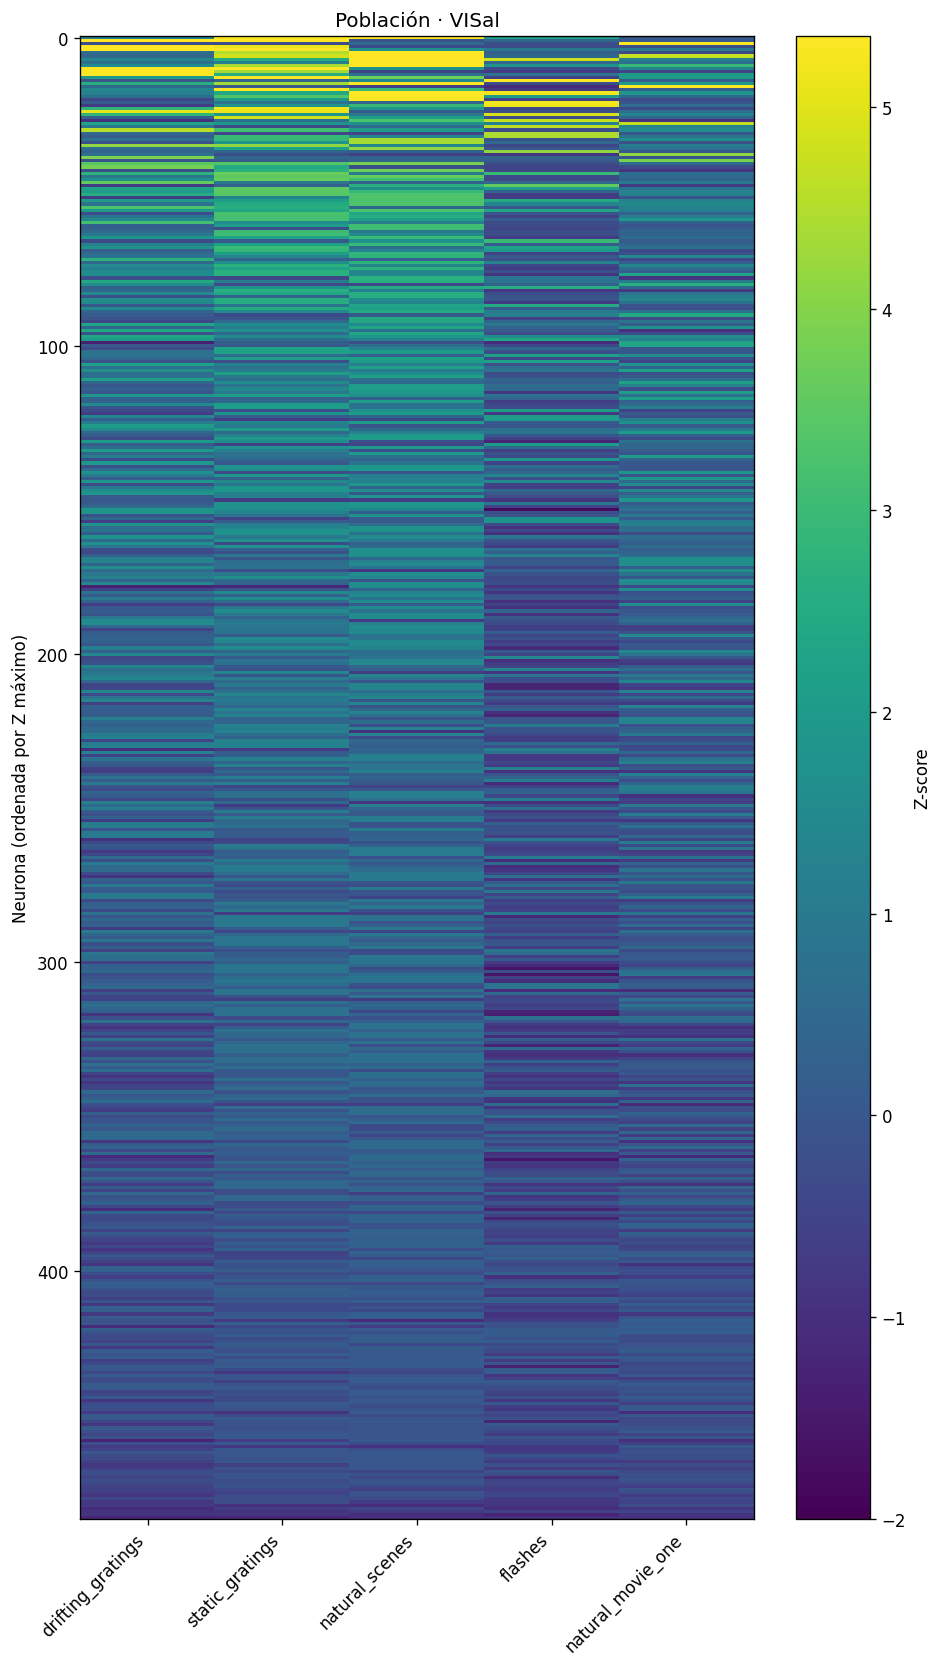

In [ ]:
# Figura 2, Panel C: heatmap neurona x estímulo (Z-score de cada clase vs. basal propia)

clases_estimulo = ["drifting_gratings", "static_gratings", "natural_scenes", "flashes", "natural_movie_one"]
ventanas_estimulo = {
    "drifting_gratings": (0, 2.0),
    "static_gratings":   (0, 0.25),
    "natural_scenes":    (0, 0.25),
    "flashes":           (0, 0.25),
    "natural_movie_one": (0, 30.0),
}

matriz_z_clases = np.full((n_neuronas, len(clases_estimulo)), np.nan)

for raton in ratones:
    neuronas_raton = np.where(d["u_raton"] == raton)[0]
    basal_raton = np.where(d["e_raton"][idx_spontaneous] == raton)[0]

    basal_media_vec = tasa_basal[neuronas_raton][:, basal_raton].mean(axis=1)
    basal_std_vec   = tasa_basal[neuronas_raton][:, basal_raton].std(axis=1)

    for j, clase in enumerate(clases_estimulo):
        idx_clase = np.where(d["e_clase"] == clase)[0]
        idx_clase_raton = idx_clase[d["e_raton"][idx_clase] == raton]

        t0, t1 = ventanas_estimulo[clase]
        dur = t1 - t0
        mask_ventana = (s_t >= t0) & (s_t < t1)

        pos_map = -np.ones(n_ensayos, dtype=int)
        pos_map[idx_clase_raton] = np.arange(len(idx_clase_raton))

        conteo = np.zeros((n_neuronas, len(idx_clase_raton)))
        es_spike = mask_ventana & (pos_map[s_ensayo] >= 0)
        np.add.at(conteo, (s_unidad[es_spike], pos_map[s_ensayo[es_spike]]), 1)
        tasa_clase = conteo / dur

        media_evocada_vec = tasa_clase[neuronas_raton].mean(axis=1)

        z_vec = np.where(basal_std_vec > 0,
                          (media_evocada_vec - basal_media_vec) / basal_std_vec,
                          np.nan)
        matriz_z_clases[neuronas_raton, j] = z_vec

# heatmap
orden = np.argsort(-np.nanmax(matriz_z_clases, axis=1))
vmax = np.nanpercentile(matriz_z_clases, 99)

plt.figure(figsize=(8, 14), dpi=120)
plt.imshow(matriz_z_clases[orden], aspect="auto", cmap="viridis",
           vmin=-2, vmax=vmax, interpolation="nearest")
plt.colorbar(label="Z-score")
plt.xticks(range(len(clases_estimulo)), clases_estimulo, rotation=45, ha="right")
plt.ylabel("Neurona (ordenada por Z máximo)")
plt.title(f"Población · {MI_AREA}")
plt.tight_layout()
plt.show()

El mapa de calor muestra cómo responde cada una de las 481 neuronas de VISal a cinco tipos de estímulos visuales. Cada fila es una neurona, cada columna un estímulo, y el color indica cuánto respondió (amarillo = mucha respuesta, azul = poca o nada). y se ve que no todas responden a lo mismo: cada una tiene su estímulo preferido, lo que significa que la población de VISal es diversa y no reacciona igual a todo.



---



In [ ]:
# Z-score por neurona, fijando la frecuencia temporal, emparejado por ratón

def calcular_z_por_tf(valor_tf):
    z = np.full(n_neuronas, np.nan)
    for raton in ratones:
        neuronas_raton = np.where(d["u_raton"] == raton)[0]
        grat_raton  = np.where(d["e_raton"][ens_rejilla] == raton)[0]
        basal_raton = np.where(d["e_raton"][idx_spontaneous] == raton)[0]

        tf_raton = e_frec_temporal[ens_rejilla][grat_raton]
        grat_cond = grat_raton[tf_raton == valor_tf]

        for n in neuronas_raton:
            basal_media = tasa_basal[n, basal_raton].mean()
            basal_std   = tasa_basal[n, basal_raton].std()
            if basal_std == 0:
                continue
            tasa_cond = tasa_evocada[n, grat_cond].mean()
            z[n] = (tasa_cond - basal_media) / basal_std
    return z

z_1hz  = calcular_z_por_tf(1)
z_15hz = calcular_z_por_tf(15)

print("Z-score mediano a 1 Hz:", np.nanmedian(z_1hz))
print("Z-score mediano a 15 Hz:", np.nanmedian(z_15hz))

Z-score mediano a 1 Hz: 0.2313896600583393
Z-score mediano a 15 Hz: -0.04300880314135364


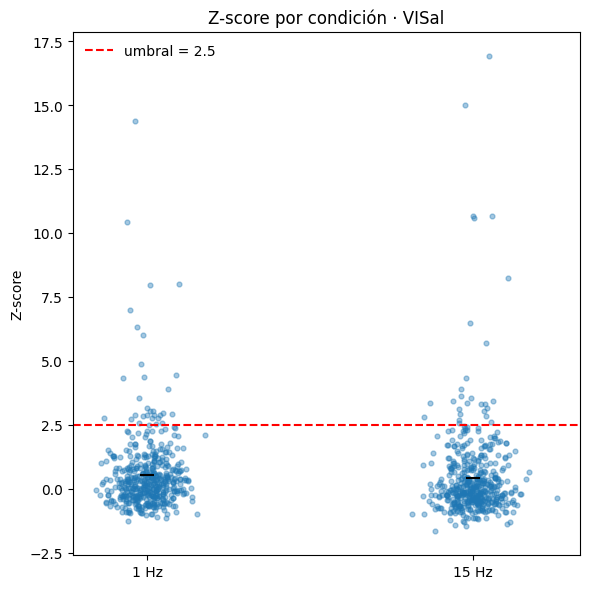

In [ ]:
# Figura 2, Panel D: enjambre de Z-score, un punto por neurona, por condición

plt.figure(figsize=(6, 6))

for x, z_vals, nombre in [(0, z_1hz, "1 Hz"), (1, z_15hz, "15 Hz")]:
    y = z_vals[~np.isnan(z_vals)]
    x_jitter = np.random.normal(x, 0.06, size=len(y))
    plt.scatter(x_jitter, y, s=12, alpha=0.4, color="tab:blue")
    plt.scatter([x], [np.nanmean(z_vals)], s=100, color="black", zorder=5, marker="_")

UMBRAL = 2.5
plt.axhline(UMBRAL, color="red", linestyle="--", label=f"umbral = {UMBRAL}")
plt.xticks([0, 1], ["1 Hz", "15 Hz"])
plt.ylabel("Z-score")
plt.title(f"Z-score por condición · {MI_AREA}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Fracción respondedora a 1 Hz:  6.2%
Fracción respondedora a 15 Hz: 5.6%
IC 95% fracción 1 Hz:  [4.1%, 9.7%]
IC 95% fracción 15 Hz: [3.7%, 10.8%]
IC 95% diferencia (15Hz - 1Hz): [-2.9%, 3.6%]

Valor p (permutación pareada): 0.7203
d de Cohen: -0.08

[comparación pedida en el enunciado] t-test pareado ignorando ratón: p = 0.077835
(comparar este p, y el intervalo de un IC basado en ese t-test, contra el del bootstrap jerárquico de arriba)


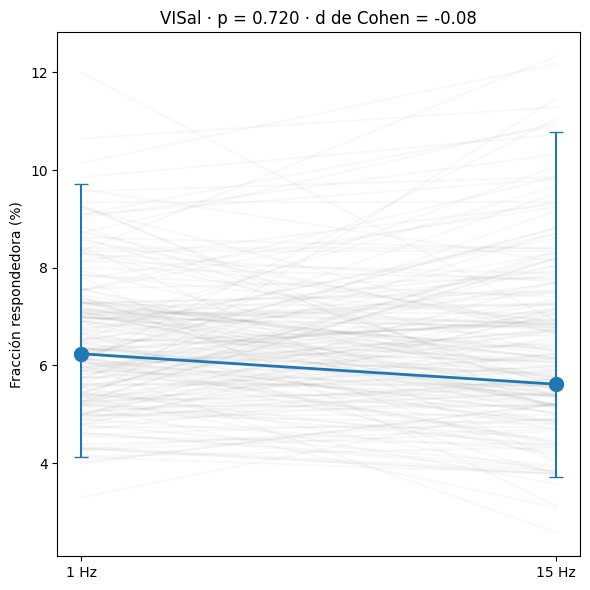

In [ ]:
# Preparar estructura por ratón: qué neuronas y qué ensayos usar

datos_por_raton = {}

for raton in ratones:
    neuronas_raton = np.where(d["u_raton"] == raton)[0]
    grat_raton  = np.where(d["e_raton"][ens_rejilla] == raton)[0]
    basal_raton = np.where(d["e_raton"][idx_spontaneous] == raton)[0]

    tf_raton = e_frec_temporal[ens_rejilla][grat_raton]
    grat_1hz  = grat_raton[tf_raton == 1]
    grat_15hz = grat_raton[tf_raton == 15]

    datos_por_raton[raton] = {
        "neuronas": neuronas_raton,
        "basal": tasa_basal[neuronas_raton][:, basal_raton],
        "cond_1hz": tasa_evocada[neuronas_raton][:, grat_1hz],
        "cond_15hz": tasa_evocada[neuronas_raton][:, grat_15hz],
    }

UMBRAL = 2.5

def calcular_fracciones_observadas():
    z1_todas, z15_todas = [], []
    for raton in ratones:
        info = datos_por_raton[raton]
        basal_media = info["basal"].mean(axis=1)
        basal_std   = info["basal"].std(axis=1)
        valido = basal_std > 0
        z1  = np.where(valido, (info["cond_1hz"].mean(axis=1)  - basal_media) / basal_std, np.nan)
        z15 = np.where(valido, (info["cond_15hz"].mean(axis=1) - basal_media) / basal_std, np.nan)
        z1_todas.append(z1); z15_todas.append(z15)
    z1_todas  = np.concatenate(z1_todas)
    z15_todas = np.concatenate(z15_todas)
    frac_1  = np.nanmean(z1_todas  >= UMBRAL)
    frac_15 = np.nanmean(z15_todas >= UMBRAL)
    return frac_1, frac_15, z1_todas, z15_todas

frac_1_obs, frac_15_obs, z1_obs, z15_obs = calcular_fracciones_observadas()
print(f"Fracción respondedora a 1 Hz:  {frac_1_obs*100:.1f}%")
print(f"Fracción respondedora a 15 Hz: {frac_15_obs*100:.1f}%")


# Bootstrap jerárquico de 3 niveles (ratón -> neurona -> ensayo)

N_REPS = 10000
diffs_boot = np.zeros(N_REPS)
frac1_boot = np.zeros(N_REPS)
frac15_boot = np.zeros(N_REPS)

rng = np.random.default_rng(0)

for r in range(N_REPS):
    ratones_boot = rng.choice(ratones, size=len(ratones), replace=True)  # nivel 1: ratones

    z1_rep, z15_rep = [], []
    for raton in ratones_boot:
        info = datos_por_raton[raton]
        Nm = len(info["neuronas"])
        neuronas_boot = rng.integers(0, Nm, size=Nm)  # nivel 2: neuronas dentro del ratón

        Tb  = info["basal"].shape[1]
        T1  = info["cond_1hz"].shape[1]
        T15 = info["cond_15hz"].shape[1]

        # nivel 3: ensayos, con reemplazo, para cada neurona resampleada
        idx_b  = rng.integers(0, Tb,  size=(Nm, Tb))
        idx_1  = rng.integers(0, T1,  size=(Nm, T1))
        idx_15 = rng.integers(0, T15, size=(Nm, T15))

        basal_b  = info["basal"][neuronas_boot][np.arange(Nm)[:, None], idx_b]
        cond1_b  = info["cond_1hz"][neuronas_boot][np.arange(Nm)[:, None], idx_1]
        cond15_b = info["cond_15hz"][neuronas_boot][np.arange(Nm)[:, None], idx_15]

        basal_media_b = basal_b.mean(axis=1)
        basal_std_b   = basal_b.std(axis=1)
        valido = basal_std_b > 0

        with np.errstate(divide='ignore', invalid='ignore'):
            z1  = np.where(valido, (cond1_b.mean(axis=1)  - basal_media_b) / basal_std_b, np.nan)
            z15 = np.where(valido, (cond15_b.mean(axis=1) - basal_media_b) / basal_std_b, np.nan)
        z1_rep.append(z1); z15_rep.append(z15)

    z1_rep  = np.concatenate(z1_rep)
    z15_rep = np.concatenate(z15_rep)

    f1  = np.nanmean(z1_rep  >= UMBRAL)
    f15 = np.nanmean(z15_rep >= UMBRAL)
    frac1_boot[r]  = f1
    frac15_boot[r] = f15
    diffs_boot[r]  = f15 - f1

ic_1hz  = np.percentile(frac1_boot,  [2.5, 97.5])
ic_15hz = np.percentile(frac15_boot, [2.5, 97.5])
ic_diff = np.percentile(diffs_boot,  [2.5, 97.5])

print(f"IC 95% fracción 1 Hz:  [{ic_1hz[0]*100:.1f}%, {ic_1hz[1]*100:.1f}%]")
print(f"IC 95% fracción 15 Hz: [{ic_15hz[0]*100:.1f}%, {ic_15hz[1]*100:.1f}%]")
print(f"IC 95% diferencia (15Hz - 1Hz): [{ic_diff[0]*100:.1f}%, {ic_diff[1]*100:.1f}%]")



# Prueba de permutación (pareada, a nivel de neurona)

diferencia_observada = frac_15_obs - frac_1_obs

mask_ambas = ~np.isnan(z1_obs) & ~np.isnan(z15_obs)
z1_pares  = z1_obs[mask_ambas]
z15_pares = z15_obs[mask_ambas]
n_pares = len(z1_pares)

N_PERM = 10000
diffs_perm = np.zeros(N_PERM)
for p in range(N_PERM):
    swap = rng.random(n_pares) < 0.5   # para cada neurona, con 50% de chance, intercambia sus dos condiciones
    a = np.where(swap, z15_pares, z1_pares)
    b = np.where(swap, z1_pares, z15_pares)
    diffs_perm[p] = np.mean(b >= UMBRAL) - np.mean(a >= UMBRAL)

p_valor = np.mean(np.abs(diffs_perm) >= np.abs(diferencia_observada))
print(f"\nValor p (permutación pareada): {p_valor:.4f}")



# d de Cohen (sobre la diferencia de Z-score por neurona)

diferencia_pareada = z15_pares - z1_pares
d_cohen = diferencia_pareada.mean() / diferencia_pareada.std()
print(f"d de Cohen: {d_cohen:.2f}")


# Comparación: bootstrap jerárquico vs. t-test que ignora el ratón

from scipy import stats
t_stat, p_ttest = stats.ttest_rel(z15_pares, z1_pares)
print(f"\n[comparación pedida en el enunciado] t-test pareado ignorando ratón: p = {p_ttest:.6f}")
print("(comparar este p, y el intervalo de un IC basado en ese t-test, contra el del bootstrap jerárquico de arriba)")


# Panel E: gráfica final

plt.figure(figsize=(6, 6))

# líneas finas de una muestra de réplicas del bootstrap (para dar sensación de variabilidad)
idx_muestra = rng.choice(N_REPS, size=200, replace=False)
for i in idx_muestra:
    plt.plot([0, 1], [frac1_boot[i]*100, frac15_boot[i]*100], color="gray", alpha=0.05)

plt.plot([0, 1], [frac_1_obs*100, frac_15_obs*100], color="tab:blue", marker="o", markersize=10, linewidth=2)
plt.errorbar([0, 1], [frac_1_obs*100, frac_15_obs*100],
             yerr=[[frac_1_obs*100 - ic_1hz[0]*100, frac_15_obs*100 - ic_15hz[0]*100],
                   [ic_1hz[1]*100 - frac_1_obs*100, ic_15hz[1]*100 - frac_15_obs*100]],
             fmt="none", color="tab:blue", capsize=5)

plt.xticks([0, 1], ["1 Hz", "15 Hz"])
plt.ylabel("Fracción respondedora (%)")
plt.title(f"{MI_AREA} · p = {p_valor:.3f} · d de Cohen = {d_cohen:.2f}")
plt.tight_layout()
plt.show()

In [ ]:
# Bootstrap PLANO (ingenuo): ignora que las neuronas vienen agrupadas por ratón

diffs_plano = np.zeros(N_REPS)
n_neuronas_validas = np.sum(mask_ambas)

for r in range(N_REPS):
    idx_boot = rng.integers(0, n_neuronas_validas, size=n_neuronas_validas)  # un solo nivel de remuestreo
    z1_p  = z1_pares[idx_boot]
    z15_p = z15_pares[idx_boot]
    diffs_plano[r] = np.mean(z15_p >= UMBRAL) - np.mean(z1_p >= UMBRAL)

ic_plano = np.percentile(diffs_plano, [2.5, 97.5])

ancho_jerarquico = ic_diff[1] - ic_diff[0]
ancho_plano = ic_plano[1] - ic_plano[0]

print(f"IC 95% diferencia (bootstrap JERÁRQUICO): [{ic_diff[0]*100:.1f}%, {ic_diff[1]*100:.1f}%]  → ancho = {ancho_jerarquico*100:.1f} pp")
print(f"IC 95% diferencia (bootstrap PLANO, ignora ratón): [{ic_plano[0]*100:.1f}%, {ic_plano[1]*100:.1f}%]  → ancho = {ancho_plano*100:.1f} pp")
print(f"\nEl IC plano es {ancho_plano/ancho_jerarquico:.2f}x el ancho del jerárquico")

IC 95% diferencia (bootstrap JERÁRQUICO): [-2.9%, 3.6%]  → ancho = 6.5 pp
IC 95% diferencia (bootstrap PLANO, ignora ratón): [-2.9%, 1.7%]  → ancho = 4.6 pp

El IC plano es 0.70x el ancho del jerárquico


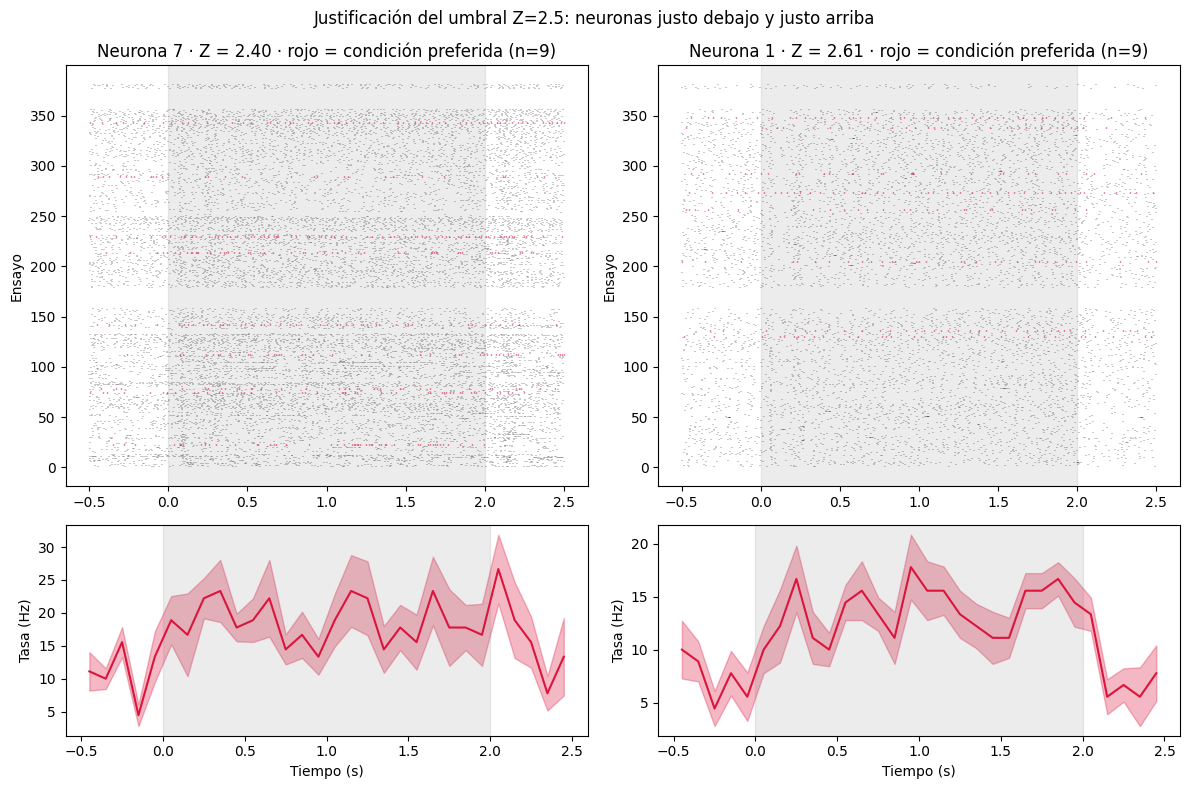

In [ ]:
# Justificación del umbral: comparar rasters de neuronas justo debajo y justo arriba de Z=2.5

def graficar_raster_condicion_preferida(n, ax_raster, ax_psth):
    raton_n = d["u_raton"][n]
    grat_raton_n = np.where(d["e_raton"][ens_rejilla] == raton_n)[0]

    orient_n = e_orientacion[ens_rejilla][grat_raton_n]
    tf_n     = e_frec_temporal[ens_rejilla][grat_raton_n]
    sf_n     = e_frec_espacial[ens_rejilla][grat_raton_n]

    mask_v = ~np.isnan(orient_n) & ~np.isnan(tf_n) & ~np.isnan(sf_n)
    grat_raton_n_v = grat_raton_n[mask_v]
    orient_n, tf_n, sf_n = orient_n[mask_v], tf_n[mask_v], sf_n[mask_v]

    combos_n = np.stack([orient_n, tf_n, sf_n], axis=1)
    combos_unicas_n, combo_id_n = np.unique(combos_n, axis=0, return_inverse=True)

    basal_raton_n = np.where(d["e_raton"][idx_spontaneous] == raton_n)[0]
    basal_media_n = tasa_basal[n, basal_raton_n].mean()
    basal_std_n   = tasa_basal[n, basal_raton_n].std()
    tasas_n = tasa_evocada[n, grat_raton_n_v]

    z_por_combo_n = np.array([
        (tasas_n[combo_id_n == c].mean() - basal_media_n) / basal_std_n
        for c in range(len(combos_unicas_n))
    ])
    combo_pref_n = np.argmax(z_por_combo_n)
    es_preferido_n = (combo_id_n == combo_pref_n)

    ensayos_globales_n = ens_rejilla[grat_raton_n_v]
    raster_n = alinear_neurona(n, ensayos_globales_n, ventana=(-0.5, 2.5))

    # raster
    for fila, spikes in enumerate(raster_n):
        color = "crimson" if es_preferido_n[fila] else "black"
        grosor = 1.0 if es_preferido_n[fila] else 0.3
        ax_raster.vlines(spikes, fila, fila + 0.9, color=color, linewidth=grosor)
    ax_raster.axvspan(0, 2, color="gray", alpha=0.15)
    ax_raster.set_title(f"Neurona {n} · Z = {z_scores[n]:.2f} · rojo = condición preferida (n={es_preferido_n.sum()})")
    ax_raster.set_ylabel("Ensayo")

    # PSTH solo de la condición preferida
    spikes_preferidos = [s for s, pref in zip(raster_n, es_preferido_n) if pref]
    bin_size = 0.1
    bordes = np.arange(-0.5, 2.5 + bin_size, bin_size)
    centros = bordes[:-1] + bin_size / 2
    conteos = np.array([np.histogram(s, bins=bordes)[0] / bin_size for s in spikes_preferidos])
    media = conteos.mean(axis=0)
    sem = conteos.std(axis=0) / np.sqrt(len(spikes_preferidos))
    ax_psth.plot(centros, media, color="crimson")
    ax_psth.fill_between(centros, media - sem, media + sem, color="crimson", alpha=0.3)
    ax_psth.axvspan(0, 2, color="gray", alpha=0.15)
    ax_psth.set_xlabel("Tiempo (s)")
    ax_psth.set_ylabel("Tasa (Hz)")


# ---- comparar neurona justo debajo (7) y justo arriba (1) del umbral ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1]})

graficar_raster_condicion_preferida(7, axes[0, 0], axes[1, 0])   # Z = 2.40, debajo
graficar_raster_condicion_preferida(1, axes[0, 1], axes[1, 1])   # Z = 2.61, arriba

plt.suptitle("Justificación del umbral Z=2.5: neuronas justo debajo y justo arriba")
plt.tight_layout()
plt.show()

In [ ]:
# Verificación final: mediana de tasa evocada, bien emparejada por ratón

medianas_por_neurona = []
for raton in ratones:
    neuronas_raton = np.where(d["u_raton"] == raton)[0]
    grat_raton = np.where(d["e_raton"][ens_rejilla] == raton)[0]
    for n in neuronas_raton:
        medianas_por_neurona.append(np.median(tasa_evocada[n, grat_raton]))

print("Mediana tasa evocada (verificación final):", np.median(medianas_por_neurona))

Mediana tasa evocada (verificación final): 2.0


In [ ]:
# Chequeo de salud del bootstrap: comparar el IC con el rango de las 5 fracciones por ratón

fracciones_por_raton_1hz = []
fracciones_por_raton_15hz = []

for raton in ratones:
    info = datos_por_raton[raton]
    basal_media = info["basal"].mean(axis=1)
    basal_std   = info["basal"].std(axis=1)
    valido = basal_std > 0
    with np.errstate(divide='ignore', invalid='ignore'):
        z1  = np.where(valido, (info["cond_1hz"].mean(axis=1)  - basal_media) / basal_std, np.nan)
        z15 = np.where(valido, (info["cond_15hz"].mean(axis=1) - basal_media) / basal_std, np.nan)
    fracciones_por_raton_1hz.append(np.nanmean(z1 >= UMBRAL))
    fracciones_por_raton_15hz.append(np.nanmean(z15 >= UMBRAL))

rango_1hz  = max(fracciones_por_raton_1hz) - min(fracciones_por_raton_1hz)
rango_15hz = max(fracciones_por_raton_15hz) - min(fracciones_por_raton_15hz)

print("Fracción por ratón (1 Hz):", [f"{f*100:.1f}%" for f in fracciones_por_raton_1hz])
print("Fracción por ratón (15 Hz):", [f"{f*100:.1f}%" for f in fracciones_por_raton_15hz])
print(f"\nRango entre ratones (1 Hz): {rango_1hz*100:.1f} pp")
print(f"Rango entre ratones (15 Hz): {rango_15hz*100:.1f} pp")
print(f"Ancho del IC jerárquico (1 Hz): {(ic_1hz[1]-ic_1hz[0])*100:.1f} pp")
print(f"Ancho del IC jerárquico (15 Hz): {(ic_15hz[1]-ic_15hz[0])*100:.1f} pp")

Fracción por ratón (1 Hz): ['9.6%', '8.8%', '3.7%', '6.5%', '7.6%']
Fracción por ratón (15 Hz): ['13.5%', '5.3%', '2.7%', '6.5%', '6.5%']

Rango entre ratones (1 Hz): 5.9 pp
Rango entre ratones (15 Hz): 10.8 pp
Ancho del IC jerárquico (1 Hz): 5.6 pp
Ancho del IC jerárquico (15 Hz): 7.1 pp


In [ ]:
# Diagnóstico limpio: bootstrap SIN sortear ratones (deja fijos los 5), solo niveles 2 y 3

diffs_sin_nivel1 = np.zeros(N_REPS)

for r in range(N_REPS):
    z1_rep, z15_rep = [], []
    for raton in ratones:  # usamos los 5 ratones fijos, siempre los mismos
        info = datos_por_raton[raton]
        Nm = len(info["neuronas"])
        neuronas_boot = rng.integers(0, Nm, size=Nm)

        Tb  = info["basal"].shape[1]
        T1  = info["cond_1hz"].shape[1]
        T15 = info["cond_15hz"].shape[1]
        idx_b  = rng.integers(0, Tb,  size=(Nm, Tb))
        idx_1  = rng.integers(0, T1,  size=(Nm, T1))
        idx_15 = rng.integers(0, T15, size=(Nm, T15))

        basal_b  = info["basal"][neuronas_boot][np.arange(Nm)[:, None], idx_b]
        cond1_b  = info["cond_1hz"][neuronas_boot][np.arange(Nm)[:, None], idx_1]
        cond15_b = info["cond_15hz"][neuronas_boot][np.arange(Nm)[:, None], idx_15]

        basal_media_b = basal_b.mean(axis=1)
        basal_std_b   = basal_b.std(axis=1)
        valido = basal_std_b > 0
        with np.errstate(divide='ignore', invalid='ignore'):
            z1  = np.where(valido, (cond1_b.mean(axis=1)  - basal_media_b) / basal_std_b, np.nan)
            z15 = np.where(valido, (cond15_b.mean(axis=1) - basal_media_b) / basal_std_b, np.nan)
        z1_rep.append(z1); z15_rep.append(z15)

    z1_rep, z15_rep = np.concatenate(z1_rep), np.concatenate(z15_rep)
    diffs_sin_nivel1[r] = np.nanmean(z15_rep >= UMBRAL) - np.nanmean(z1_rep >= UMBRAL)

ic_sin_nivel1 = np.percentile(diffs_sin_nivel1, [2.5, 97.5])
ancho_sin_nivel1 = ic_sin_nivel1[1] - ic_sin_nivel1[0]

print(f"IC diferencia CON sorteo de ratones (3 niveles): [{ic_diff[0]*100:.1f}%, {ic_diff[1]*100:.1f}%] → ancho = {ancho_jerarquico*100:.1f} pp")
print(f"IC diferencia SIN sorteo de ratones (2 niveles):  [{ic_sin_nivel1[0]*100:.1f}%, {ic_sin_nivel1[1]*100:.1f}%] → ancho = {ancho_sin_nivel1*100:.1f} pp")

IC diferencia CON sorteo de ratones (3 niveles): [-2.9%, 3.6%] → ancho = 6.5 pp
IC diferencia SIN sorteo de ratones (2 niveles):  [-2.5%, 2.5%] → ancho = 5.0 pp
